In [2]:
import os
import yaml 
import gc
import matplotlib.pyplot as plt


In [3]:
from generic.distributed import Distributed
distributed= Distributed.get_instance()

# individually

## Test IO

In [4]:
from data.utils_data import ModelDataConfig, ObsDataConfig, ConditionDataConfig
from preprocessing.preprocessing import *


from preprocessing.utils_preprocessing import *
from data.datasets import *

In [5]:
from data.dataloader import *

In [6]:
expe_dir = Path("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test")
os.environ["GLOBAL_EXP_DIR"] = str(expe_dir)

os.environ["GLOBAL_CHECKPOINT_DIR"] = os.path.join(expe_dir, "training_checkpoints")
os.environ["GLOBAL_FIGURES_DIR"] = os.path.join(expe_dir, "figures")
os.environ["GLOBAL_LOG_DIR"] = os.path.join(expe_dir, "logs")

checkpoint_dir = os.path.join(expe_dir, "training_checkpoints")
figures_dir = os.path.join(expe_dir, "figures")
log_dir = os.path.join(expe_dir, "logs")

In [7]:
model_path = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data'
# observation_path = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/observations'
input_pp = PreprocessingPipeline([PreprocessingStepSelector(name = 'anomalies') ]) #,PreprocessingStepSelector(name = 'oceannanremover')])
target_pp = PreprocessingPipeline([PreprocessingStepSelector(name = 'standardizer')]) #,PreprocessingStepSelector(name = 'oceannanremover')])
name = ['tas']

model = ModelDataConfig(paths = model_path, names = name, preprocessing_pipeline=input_pp, concat_dim='year')
observation = None #ObsDataConfig(paths = observation_path, names = name, preprocessing_pipeline=target_pp, concat_dim='year', rename_dims_dict={'lead_time' : 'month'})

In [8]:
config_ds = XArrayDatasetConfig(model=model, observation= observation, time_features=['year'], condition_method='ensemble_mean')

#### test dataset config

In [8]:
# config_ds.model.paths

In [9]:
# config_ds.available_train_time


In [10]:
# print('common time: ', config_ds.get_common_time)
# print('available train time: ', config_ds.available_train_time)

In [8]:
## test saving:
config_ds._fit_preprocessors(train_years = [1980,2000])
## test loading:
# config_ds._load_fitted_preprocessors(load_dir= '.')

In [ ]:
# config_ds.model.preprocessing_pipeline.get_preprocessors('anomalies').mean
# 

<xarray.Dataset> Size: 12B
Dimensions:  ()
Coordinates:
    height   float64 8B 2.0
Data variables:
    tas      float32 4B 278.5

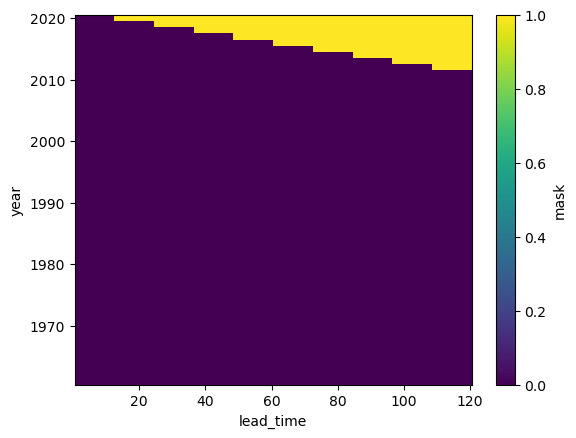

In [18]:


def _create_train_mask(years : list | xr.DataArray , lead_times: list | xr.DataArray |int , exclude_idx=0):

    if isinstance(lead_times , int):
        lead_times = np.arange(1, lead_times+1)

    mask = np.full((len(years), len(lead_times)), False, dtype=bool)
    x = np.arange(0, 12*mask.shape[0], 12)   
    y = np.arange(1, mask.shape[1] + 1)
    idx_array = x[..., None] + y
    # mask[idx_array >= idx_array[-1, exclude_idx + 12]] = True
    mask[idx_array > idx_array[-1, exclude_idx + 11]] = True

    return xr.DataArray(
        mask,
        dims=('year', 'lead_time'),
        coords={'year': years, 'lead_time': lead_times},
        name="mask"
    )

mask = _create_train_mask(config_ds.available_train_time, config_ds.num_model_lead_months)
mask.plot()

In [14]:
# config_ds.get_common_time

In [9]:
dataset = config_ds.build(years =[1980,2000] , mask = None, return_metadata = False)

In [10]:
dataset._autoencoding_input

True

In [16]:
# dataset.mask

In [13]:
dataset[0]['target'].shape

torch.Size([1, 60, 120])

In [12]:
# dataset = config_ds.build(config_ds.available_train_time, mask = mask)

#### test dataloader config

In [8]:
trainlodaer_config = TrainDataloaderConfig(config_ds,train_years = [1980,1982], batch_size = 10, num_data_workers=0)

In [9]:
trainlodaer_config.setup_distributed(distributed)
train_loader = trainlodaer_config.build_train_loader(return_spatial_mask=False)

In [ ]:
# len(train_loader.dataset)

72

In [26]:
# train_loader.dataset[0]

In [ ]:
data = next(iter(train_loader))

/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/data/datasets.py:416: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1702400410390/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  added_features = torch.as_tensor(time_features, dtype=torch.float32)


In [30]:
# train_loader.dataset.config.target_info.coords['lat'].size

## test losses

In [31]:
from loss.utils_loss import *
from loss.loss import *


In [32]:
loss_config = LosspipelineConfig(
    loss_pipeline = [ LossStepConfig(name = 'mse' , args =  {'low_ress_kernel_size':3})],
    reduction='sum'
    # loss_weights= [0.2,0.8] 
)

In [33]:
weights = config_ds.get_weights()

In [34]:
weights

<xarray.DataArray 'weights' (ref: 8256)> Size: 66kB
array([1., 1., 1., ..., 1., 1., 1.])
Coordinates:
  * ref      (ref) object 66kB MultiIndex
  * lat      (ref) float64 66kB -87.86 -87.86 -87.86 ... 87.86 87.86 87.86
  * lon      (ref) float64 66kB 0.0 2.812 5.625 8.438 ... 354.4 357.2 360.0

In [35]:
loss = loss_config.build(weights, num_output_dimensions=1)

In [36]:
loss.pipeline

[WeightedMSE()]

In [37]:
loss.weights

<xarray.DataArray 'weights' (ref: 8256)> Size: 66kB
array([1., 1., 1., ..., 1., 1., 1.])
Coordinates:
  * ref      (ref) object 66kB MultiIndex
  * lat      (ref) float64 66kB -87.86 -87.86 -87.86 ... 87.86 87.86 87.86
  * lon      (ref) float64 66kB 0.0 2.812 5.625 8.438 ... 354.4 357.2 360.0

## test optimizer

In [6]:
from core.optimization import OptimizerConfig, LRSchedulerConfig 

In [7]:
scheculer_config = LRSchedulerConfig()
oprimConfig = OptimizerConfig(lr_scheduler_config  = scheculer_config)

In [8]:
# oprimConfig

## test module selectors

In [41]:
from core.selectors import *
from core.deterministic_module import *
from core.cVAE_module import *
from models.mlp_models import *

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/miniconda3/envs/rsaenv_neurips/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [42]:
model_conf = cVAEModelSelector(type = 'MLP' , args = {'encoder_hidden_dims' : [3000,3000,3000], 
                                                                'latent_size' : 10,
                                                                'decoder_hidden_dims': [3000,3000,3000, 5000],
                                                                'condition_embedding_dims' :  [3000,3000,10],
                                                                'condition_dependant_latent': True,
                                                                'condemb_to_decoder':  True,
                                                                'batch_normalization' : True,
                                                                'dropout_rate': 0.5,
                                                                'init_method' :  'xavier'})
                                                                                        

In [43]:
model_conf.args

{'encoder_hidden_dims': [3000, 3000, 3000],
 'latent_size': 10,
 'decoder_hidden_dims': [3000, 3000, 3000, 5000],
 'condition_embedding_dims': [3000, 3000, 10],
 'condition_dependant_latent': True,
 'condemb_to_decoder': True,
 'batch_normalization': True,
 'dropout_rate': 0.5,
 'init_method': 'xavier'}

In [44]:
flow_ = NormalizedFlowConfig([FlowSelector(type = 'RealNVP',
                                           args = { 'hidden_dim' : 5} ),
                                FlowSelector(type = 'MAF',
                                           args = { 'hidden_dim' : 5} )])

In [45]:
_config  = {'ModelConfig'  : model_conf, 
            'min_posterior_variance' :  2,
                'prior_flow_config' : flow_,
            'combined_CGCN_weight' :  0.1}

In [46]:
cVAE_config = ModuleSelector(type = 'cVAE',
                          config = _config)

In [47]:
cVAE_config

ModuleSelector(type='cVAE', config={'ModelConfig': cVAEModelSelector(type='MLP', args={'encoder_hidden_dims': [3000, 3000, 3000], 'latent_size': 10, 'decoder_hidden_dims': [3000, 3000, 3000, 5000], 'condition_embedding_dims': [3000, 3000, 10], 'condition_dependant_latent': False, 'condemb_to_decoder': True, 'batch_normalization': True, 'dropout_rate': 0.5, 'init_method': 'xavier'}), 'min_posterior_variance': 2, 'prior_flow_config': NormalizedFlowConfig(list_flows=[FlowSelector(type='RealNVP', args={'hidden_dim': 5}), FlowSelector(type='MAF', args={'hidden_dim': 5})], flow_sample_size=5000), 'combined_CGCN_weight': 0.1})

In [48]:
cVAE_ = cVAE_config.build_module(train_loader.input_shape,train_loader.target_shape, train_loader.added_features_dim)

In [49]:
train_loader.input_shape

(7200,)

In [50]:
cVAE_

cVAE(
  (model): cVAE_MLP(
    (embedding): Sequential(
      (0): Linear(in_features=7201, out_features=3000, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): BatchNorm1d(3000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): Linear(in_features=3000, out_features=3000, bias=True)
      (5): ReLU()
      (6): Dropout(p=0.5, inplace=False)
      (7): BatchNorm1d(3000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): Linear(in_features=3000, out_features=10, bias=True)
    )
    (encoder): Sequential(
      (0): Linear(in_features=8267, out_features=3000, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): BatchNorm1d(3000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): Linear(in_features=3000, out_features=3000, bias=True)
      (5): ReLU()
      (6): Dropout(p=0.5, inplace=False)
      (7): BatchNorm1d(3000, eps=1e-05, momentum=0.1, affine=True, t

In [51]:
cVAE_.init_loss_function(loss)

In [52]:
cVAE_  = cVAE_.to(distributed.device)

In [53]:
optimizer = oprimConfig.build(module =cVAE_, num_batches=len(train_loader), total_epochs=1)

## trainer test

In [5]:
from core.trainer import *

In [6]:

# for path in (checkpoint_dir , figures_dir,log_dir ):
#     if distributed.is_root():
#         os.makedirs(path, exist_ok=True)



In [56]:
from loss.kld import BetaAnnealing
beta = BetaAnnealing(beta = 0.001, num_epoch_to_warmup=10)

In [57]:
trainer_conf = TrainerConfig(
    beta_finder = beta,
    earlystoppingbuffer = 10,
    gradient_accumulation_steps =2,
    mixed_precision = True )

In [58]:
trainer = trainer_conf.build(train_data_loader=train_loader,
                             validation_data_loader=None,
                             optimization=optimizer,
                             module=cVAE_,
                             epochs = 3)

In [59]:
trainer.setup_distributed(distributed=distributed,
                          logger = None, 
                          log_every_n_epochs = 2)

Logger is None. Print is used instead ... 

 
Setting up trainer.
rank=0 | local_rank=0 | world_size=1 | device=cpu
Setting up output directory...
Trainer setup complete.


/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/miniconda3/envs/rsaenv_neurips/lib/python3.10/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [60]:
trainer.train()

Starting Training Loop...
Epoch 2/3 | train loss: 10126.928833 | global step: 8 | | early stopping counter: 0 | elapsed time: 43.48
Training finished in 65.82s


# train.py

In [3]:
def prepare_config(path: str) -> dict:
    """Get config and update with possible dotlist override."""
    with open(path) as f:
        data = yaml.safe_load(f)
    return data


In [4]:
yaml_config = '/home/rpg002/CCCma_PPP/train_config.yaml'
config_data = prepare_config(yaml_config)

In [5]:
config_data['train_loader']['train_years']

[1980, 1982]

In [6]:
from train.train_configs import *
import dacite

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/miniconda3/envs/rsaenv_neurips/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [7]:
config = dacite.from_dict(data_class=TrainConfig, data=config_data, config=dacite.Config(strict=True))


[('standardizer', <preprocessing.utils_preprocessing.Standardizer object at 0x14bd36b38c40>), ('oceannanremover', <preprocessing.utils_preprocessing.Oceannanremove object at 0x14bd44652980>)]


/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/data/datasets.py:46: UserWarning: input and taget do not have the same latitudes cooridnates.
  warnings.warn(f'input and taget do not have the same latitudes cooridnates.')
/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/data/datasets.py:48: UserWarning: input and taget do not have the same longitudes cooridnates.
  warnings.warn(f'input and taget do not have the same longitudes cooridnates.')


In [8]:
config

TrainConfig(experiment_dir=PosixPath('/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test'), epochs=3, train_loader=TrainDataloaderConfig(dataset_config=XArrayDatasetConfig(input=DataConfig(paths=['/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data/tas_Amon_1985_ensembles_198601-199512_3x3.nc', '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data/tas_Amon_1983_ensembles_198401-199312_3x3.nc', '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data/tas_Amon_1981_ensembles_198201-199112_3x3.nc', '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data/tas_Amon_2018_ensembles_201901-202812_3x3.nc', '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data/tas_Amon_2012_ensembles_201301-202212_3x3.nc', '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data/tas_Amon_1994_ensembles_199501-200412_3x3.nc', '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/

In [9]:
config.set_random_seed()

In [10]:
from generic.logger import setup_logger


In [11]:
    logger = setup_logger(name = 'training',
                          log_dir = config.log_dir )

In [12]:
config.log_dir

'/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test/logs'

In [13]:
    if distributed.is_root():
        logger.info('Setting up directories ...')

2026-05-26 00:11:57 | INFO | training | Setting up directories ...


In [14]:
config.prepare_directory(distributed) 

In [17]:
    if distributed.is_root():
        logger.info('Building trainer ...')    

2026-05-26 00:12:04 | INFO | training | Building trainer ...


In [18]:
config.train_loader.setup_distributed(distributed)

In [19]:
    train_loader = config.train_loader.build_train_loader()
    validation_loader =  config.train_loader.build_validation_loader()

/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/data/dataloader.py:136: UserWarning: Validation dataoader could not be built for num_validation_years = 0 
  warnings.warn(f'Validation dataoader could not be built for num_validation_years = {self.num_validation_years} ')


In [20]:
    num_train_batches = len(train_loader)
    input_shape = train_loader.input_shape
    output_shape = train_loader.target_shape
    added_features_dim = train_loader.added_features_dim

In [21]:
num_train_batches

8

In [22]:
input_shape

(7200,)

In [23]:
output_shape

(8256,)

In [24]:
added_features_dim

1

In [25]:
weights = train_loader.get_weights(config.weights)

In [26]:
config.experiment_dir

PosixPath('/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test')

In [29]:
    module = config.module.build_module(  input_shape = input_shape,
                                        output_shape = output_shape,
                                        added_features_dim = added_features_dim)

In [30]:
 module  = module.to(distributed.device)

In [31]:
    if distributed.distributed:
        module = torch.nn.parallel.DistributedDataParallel(module, device_ids=[distributed.local_rank], output_device=distributed.local_rank, find_unused_parameters=False)


In [32]:
    reconstruction_loss = config.losspipeline.build(weights=weights, num_output_dimensions= getattr(module.model, 'NUM_OUTPUT_DIMS', None ) or len(output_shape))

    module.init_loss_function(reconstruction_loss)


In [33]:
    optimizer = config.optimization.build(module, num_train_batches, config.epochs)


In [35]:
    trainer = config.trainer.build(
              train_data_loader  = train_loader , 
              validation_data_loader = validation_loader, 
              module = module,
              optimization = optimizer,
              epochs = config.epochs)

In [36]:
    trainer.setup_distributed(  distributed = distributed ,
                    logger = logger,
                    log_every_n_epochs = config.log_every_n_epochs,
                    save_checkpoint =  config.save_checkpoint )

2026-05-26 00:22:01 | INFO | training | Setting up trainer.
2026-05-26 00:22:01 | INFO | training | rank=0 | local_rank=0 | world_size=1 | device=cpu
2026-05-26 00:22:01 | INFO | training | Setting up output directory...
2026-05-26 00:22:01 | INFO | training | Trainer setup complete.


/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/miniconda3/envs/rsaenv_neurips/lib/python3.10/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [37]:
trainer.train()

2026-05-26 00:22:30 | INFO | training | Starting Training Loop...
2026-05-26 00:23:14 | INFO | training | Epoch 2/3 | train loss: 5012.516846 | global step: 8 | | early stopping counter: 0 | elapsed time: 44.56
2026-05-26 00:23:36 | INFO | training | Training finished in 66.61s
